### Bank Client Data:
    
    1 - age (numeric)
    
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    
    # related with the last contact of the current campaign:
    
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    
    # other attributes:
    
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    
    # social and economic context attributes
    
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

#### 1) importing Necessary Libraries:

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#### 2) Loading Data:

In [2]:
df = pd.read_csv('bank-full.csv')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.shape

(41188, 21)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

- Data has both Categorical and Numerical Features.
- There are no missing values in Data.

#### 3) Data Exploration and Transformation:

- Certain features needs to be dropped:
    - y (Target): Clustering is unsupervised. This will help clustering find similar data points unfairly.
    - duration: The data dictionary explicitly warns: "this input should only be included for benchmark purposes." duration is not known before the call is made. Including it will cluster customers based on how long they talk, rather than who they are.
    - contact, month, day_of_week: These describe the process of the marketing campaign, not the characteristics of the customer.

In [13]:
df.drop(['subscribed', 'duration', 'contact', 'month', 'day_of_week'], axis= 1, inplace= True)

In [14]:
df.head()

,age,job,marital,education,default,housing,loan,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


##### 1) age:

In [15]:
df['age']

0        56
1        57
2        37
3        40
4        56
         ..
41183    73
41184    46
41185    56
41186    44
41187    74
Name: age, Length: 41188, dtype: int64

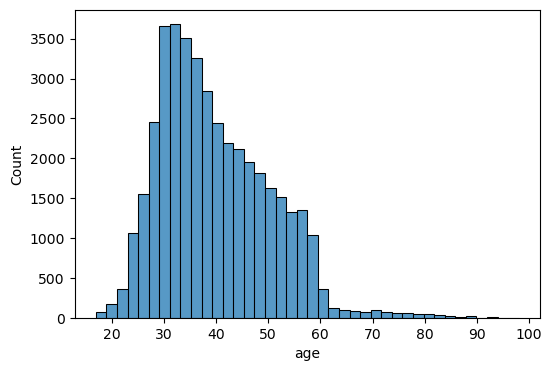

In [17]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'age', bins= 40)
plt.show()

- age has a Right Skewed Distribution.

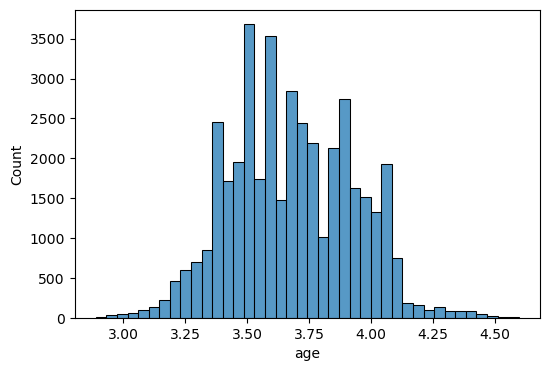

In [22]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['age'].apply(np.log1p), bins= 40)
plt.show()

- Age: Numerical Continuous Feature.
- Preprocessing:
    - Log Transformation,
    - Scaling.

In [25]:
# Preprocessing:

age_pipe = Pipeline([
    ('transformer', FunctionTransformer(np.log1p)),
    ('scalar', StandardScaler())
])

##### 2) job:

In [27]:
df['job']

0          housemaid
1           services
2           services
3             admin.
4           services
            ...     
41183        retired
41184    blue-collar
41185        retired
41186     technician
41187        retired
Name: job, Length: 41188, dtype: object

In [28]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

- job: Nominal Categorical Feature.
- Preprocessing:
    - One Hot Encoding.

In [33]:
# Preprocessing: 

job_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 3) marital:

In [31]:
df['marital']

0        married
1        married
2        married
3        married
4        married
          ...   
41183    married
41184    married
41185    married
41186    married
41187    married
Name: marital, Length: 41188, dtype: object

In [32]:
df['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

- Marital: Nominal Categorical Feature.
- Preprocessing:
    - One Hot Encoding.

In [34]:
marital_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])